# Chronos-2 Quality Net — Context Length Comparison (2026-08-27 개정)

**이번 개정에서 바뀐 것:**
- 지금까지 실험한 **11개 context_length 전부**(24 / 73 / 128 / 168 / 256 / 384 / 512 / 768 / 1024 / 1280 / 1536)를 한 번에 비교합니다.
  `context_length=24`는 학습만 되어 있고 backtest가 안 돌아가 있었어서, 이 노트북을 만들면서 새로
  `eval/backtest_{target}_predlen4_ctx24_full_v2.csv`를 생성했습니다(나머지 10개는 기존 결과 재사용).
- 호기(2CM/3CM/4CM)를 합치는 방식을 **pooled(그냥 다 합쳐서 평균) 대신 정규화(normalized) 방식**으로
  바꿨습니다 — `eval/metrics_utils.py`의 `normalized_skill_score()`. 호기별로 `model MAE / naive MAE`
  비율(1.0=naive와 동일, 낮을수록 좋음)을 구한 뒤 세 호기를 동등하게 평균 냅니다. 2CM이 원래 변동성이 더
  커서(naive baseline조차 2CM에서 더 나쁨) pooled MAE는 2CM 쪽에 자동으로 더 큰 가중치를 주는 문제가
  있었는데, 이 방식은 그걸 보정합니다. (pooled/macro-average/정규화 세 방식 모두 지금까지 검증된
  범위에서는 같은 결론을 냈지만, 정규화 방식이 원리상 가장 안전해서 이제부터 기본 지표로 씁니다.)
- **6절**: skill-score만으로는 실제 예측 정확도가 안 와닿아서, blaine·residue 각각에 대해
  **MAE / R² / Spec 정확도 / 80% 예측구간 커버리지**를 11개 context_length에 따른 꺾은선 그래프로
  그립니다(한 그림에 둘 다 + 각각 따로).
- **7절**: zero-shot / LoRA / Full fine-tuning 비교도 **11개 context_length 전부**로 확장했습니다
  (이전엔 1024까지만). 세 방식 모두 backtest가 다 있어서, 어느 context_length에서든 Full이 가장
  좋은지 꺾은선 + 막대 그래프로 확인합니다.
- 1~5절은 전부 **prediction_length=4(학습) / 1(평가)**, **Full fine-tuning** 기준입니다.
- **⚠️ loss curve(과적합 확인) 주의**: `context_length in {24, 1280, 1536}`을 제외한 나머지
  (73~1024)는, backtest에 쓰인 체크포인트(예: `blaine_full_predlen4_ctx768`)에는애초에
  `loss_history.csv`가 없습니다(학습 이력 콜백이 나중에 추가됐기 때문) — 대신 나중에 같은 설정으로
  **별도로 재학습한(`_v2`) 체크포인트**의 loss curve를 보여줍니다. 즉 이 구간의 loss curve는 "같은
  설정을 다시 돌렸을 때 학습이 어떻게 흘러가는지"를 보여줄 뿐, 옆에 나온 backtest 숫자와 완전히 같은
  학습 실행의 결과가 아닙니다(이 대화에서 여러 번 확인했듯 재학습마다 결과가 흔들릴 수 있음 — 참고만
  하세요). ctx=24/1280/1536은 애초에 실행이 한 번뿐이라 이 문제가 없습니다.

이 노트북은 GPU를 쓰지 않습니다 — 저장된 `eval/backtest_*.csv`, `checkpoints/*/loss_history.csv`만
읽습니다.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글 폰트
matplotlib.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd()
if not (ROOT / "config.py").exists():
    raise RuntimeError(
        f"config.py를 {ROOT} 에서 찾지 못했습니다. Jupyter를 chronos_quality_net 폴더에서 실행하거나, "
        "이 노트북을 그 폴더로 옮겨서 다시 여세요."
    )
sys.path.insert(0, str(ROOT))
import config as cfg
from eval.metrics_utils import compute_metrics, macro_average_mae, normalized_skill_score
from eval.loss_history import load_loss_history, overfit_summary

EVAL_DIR = ROOT / "eval"
CKPT_DIR = ROOT / "checkpoints"

TARGETS = cfg.TARGET_COLS  # ["blaine", "residue"]

# 지금까지 실험한 11개 context_length 전부 (predlen=4 학습 / 1 평가)
CONTEXTS = [24, 73, 128, 168, 256, 384, 512, 768, 1024, 1280, 1536]

# zero-shot / LoRA / Full 세 방식 모두 11개 context_length 전부 backtest 되어 있음 (7절 비교에서 사용)
CONTEXTS_ALL_METHODS = CONTEXTS
METHOD_SUFFIXES = {"zero-shot": "zeroshot", "LoRA": "lora", "Full fine-tuning": "full"}
METHODS = list(METHOD_SUFFIXES.keys())

# loss_history_path()가 참고하는, "_v2" 접미사가 붙은 (나중에 추가/재학습된) context 값들.
V2_CONTEXTS = {24, 1280, 1536}


def backtest_path(target: str, ctx: int, method: str = "Full fine-tuning") -> Path:
    """해당 (target, context_length, 방식) backtest CSV 경로.

    실험이 여러 컴퓨터/시점에 걸쳐 진행돼서 파일명 규칙이 제각각임 (`_v2` 접미사, predlen4
    포함 여부, ctx 태그 없는 최초 기본값, zero-shot 리네임 전 대문자 등). 규칙을 하드코딩하는
    대신 가능한 파일명 후보를 순서대로 시도해서 실제로 존재하는 첫 번째를 반환한다.
    존재하는 게 하나도 없으면 첫 후보를 반환한다(로딩 셀의 missing 리포트에서 잡히도록)."""
    suffix = METHOD_SUFFIXES[method]
    cands = [
        f"backtest_{target}_predlen4_ctx{ctx}_{suffix}_v2.csv",
        f"backtest_{target}_predlen4_ctx{ctx}_{suffix}.csv",
        f"backtest_{target}_ctx{ctx}_{suffix}.csv",
    ]
    if ctx == 512:
        # ctx=512 = "_ctx{N}" 태그가 생기기 전의 최초 기본값이라 태그가 없음
        cands += [
            f"backtest_{target}_predlen4_{suffix}.csv",
            f"backtest_{target}_{suffix}.csv",
        ]
        if method == "zero-shot" and target == "blaine":
            cands.append("backtest_BLAINE_zeroshot.csv")  # zero-shot만 리네임 전
    for name in cands:
        p = EVAL_DIR / name
        if p.exists():
            return p
    return EVAL_DIR / cands[0]


def loss_history_path(target: str, ctx: int) -> Path:
    # 73~1024 구간은 backtest에 쓰인 체크포인트가 아니라 나중에 다시 학습한 "_v2" 체크포인트의
    # loss curve입니다 (해당 원본 체크포인트에는 loss_history.csv가 아예 없음).
    return CKPT_DIR / f"{target}_full_predlen4_ctx{ctx}_v2" / "loss_history.csv"

print("context_length 값 (11개):", CONTEXTS)
print("targets:", TARGETS)

context_length 값 (11개): [24, 73, 128, 168, 256, 384, 512, 768, 1024, 1280, 1536]
targets: ['blaine', 'residue']


## 1. 결과 파일 로딩 (11개 context_length, Full fine-tuning)

In [2]:
full_raw = {t: {} for t in TARGETS}
missing = []
for target in TARGETS:
    for ctx in CONTEXTS:
        p = backtest_path(target, ctx)
        if p.exists():
            full_raw[target][ctx] = pd.read_csv(p, parse_dates=["timestamp"])
        else:
            missing.append(str(p))

if missing:
    print("[missing]", len(missing), "files:")
    for m in missing:
        print(" ", m)
else:
    print("11개 context_length x 2 타깃 =", sum(len(full_raw[t]) for t in TARGETS), "개 결과 파일 전부 로딩 완료")

loss_raw = {t: {} for t in TARGETS}
loss_missing = []
for target in TARGETS:
    for ctx in CONTEXTS:
        p = loss_history_path(target, ctx)
        if p.exists():
            loss_raw[target][ctx] = pd.read_csv(p)
        else:
            loss_missing.append(str(p))

if loss_missing:
    print()
    print("[loss_history missing]", len(loss_missing), "files:")
    for m in loss_missing:
        print(" ", m)
else:
    print("loss_history도 11개 x 2 타깃 전부 로딩 완료")

11개 context_length x 2 타깃 = 22 개 결과 파일 전부 로딩 완료
loss_history도 11개 x 2 타깃 전부 로딩 완료


## 2. 11개 context_length 각각 — 학습 과적합 확인 (loss curve)

파란색=blaine, 주황색=residue. 실선=train_loss, 점선=val_loss. 세로 점선은 각 타깃의 val_loss
최소 지점. 제목의 `Δval`은 `val_loss_final - val_loss_min`(0보다 크게 벌어질수록 과적합 신호).

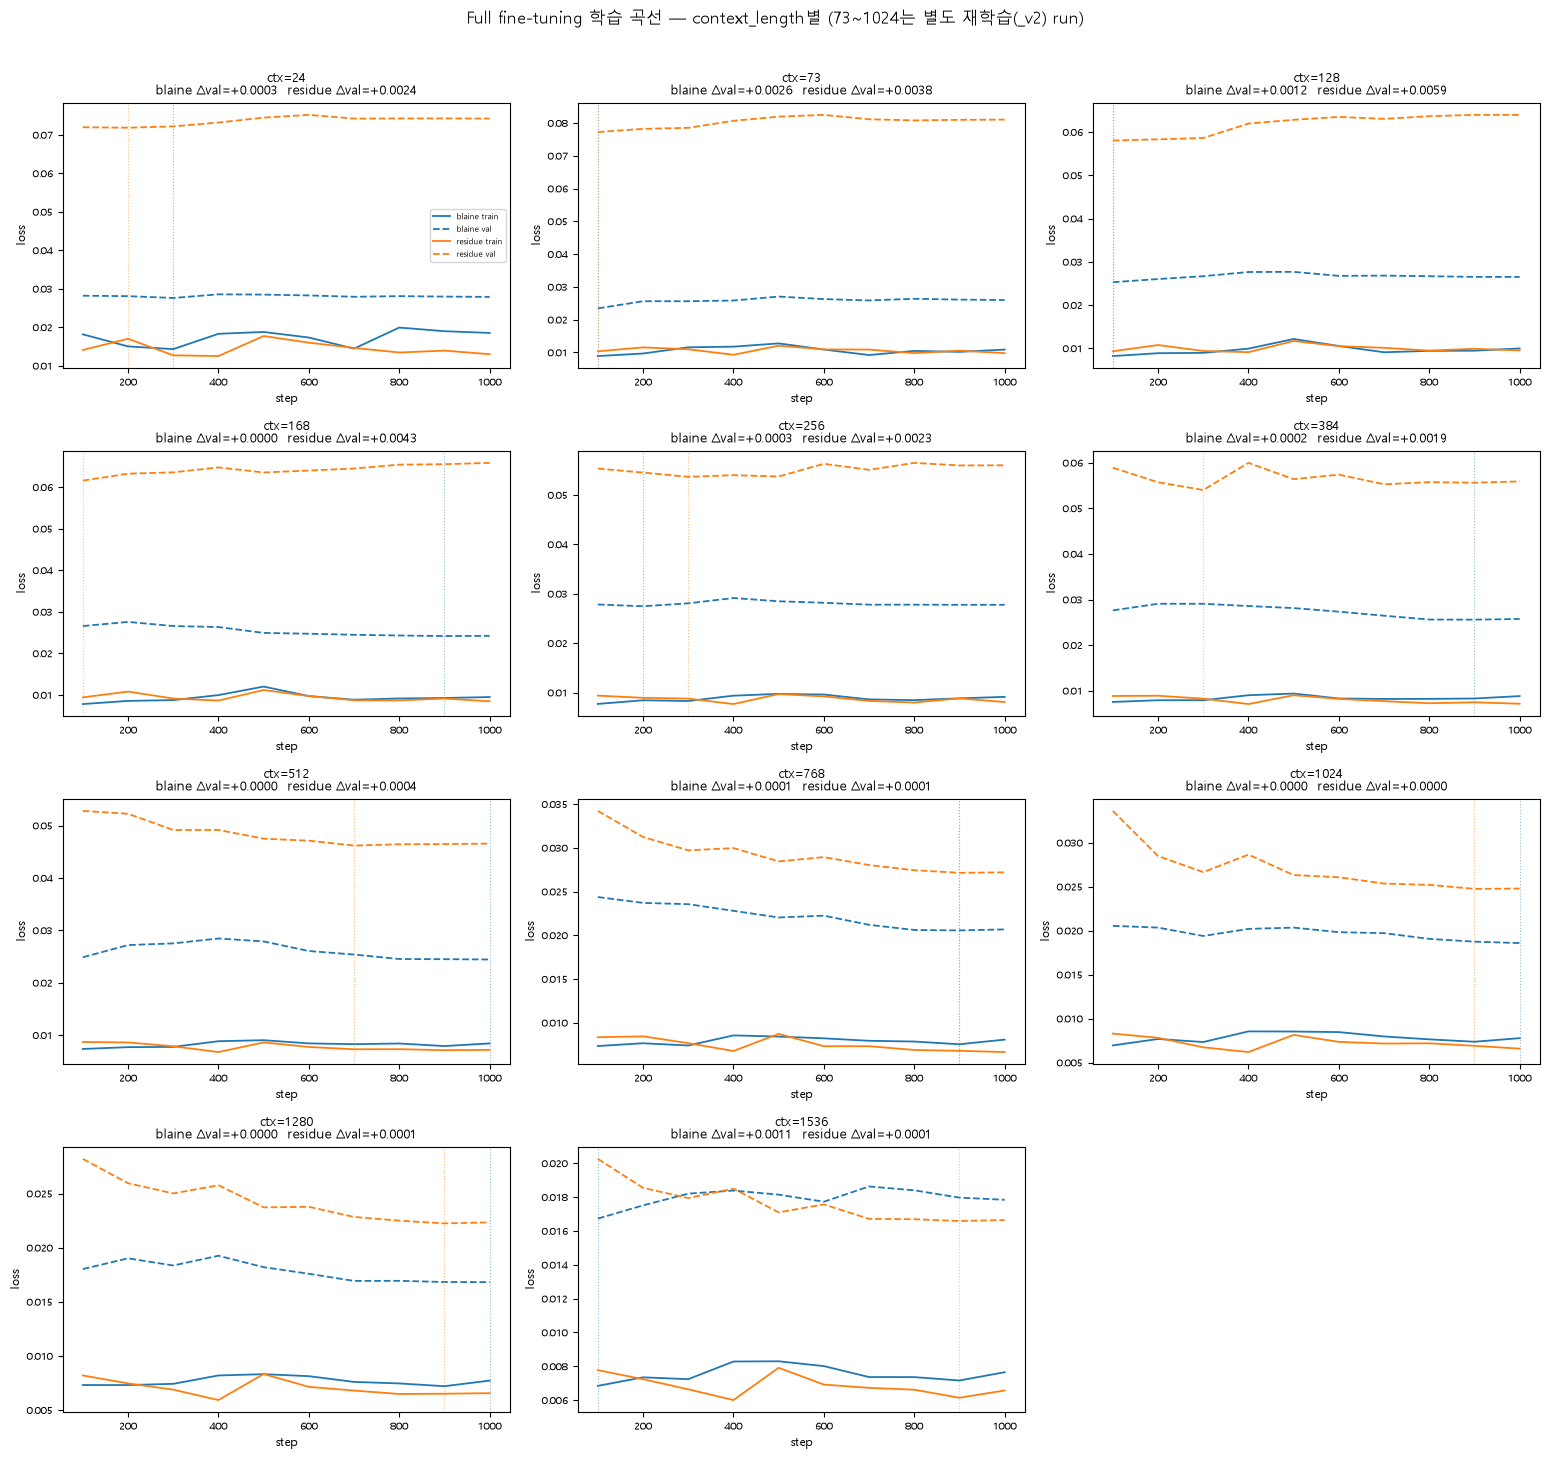

과적합 요약표 (final_minus_min이 0보다 많이 크면 과적합 의심):
 target  ctx  val_loss_min  val_loss_final  final_minus_min
 blaine   24       0.02761         0.02789          0.00028
 blaine   73       0.02344         0.02599          0.00256
 blaine  128       0.02528         0.02650          0.00122
 blaine  168       0.02418         0.02422          0.00004
 blaine  256       0.02747         0.02776          0.00028
 blaine  384       0.02558         0.02574          0.00015
 blaine  512       0.02444         0.02444          0.00000
 blaine  768       0.02056         0.02067          0.00011
 blaine 1024       0.01858         0.01858          0.00000
 blaine 1280       0.01682         0.01682          0.00000
 blaine 1536       0.01673         0.01784          0.00111
residue   24       0.07186         0.07425          0.00239
residue   73       0.07723         0.08104          0.00380
residue  128       0.05804         0.06396          0.00591
residue  168       0.06158         0.06584          0.0

In [3]:
ncols = 3
nrows = -(-len(CONTEXTS) // ncols)  # ceil
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.6 * nrows))
axes = axes.flatten()

overfit_rows = []
colors = {"blaine": ("tab:blue", "blaine"), "residue": ("tab:orange", "residue")}

for i, ctx in enumerate(CONTEXTS):
    ax = axes[i]
    for target, (color, label) in colors.items():
        df = loss_raw[target].get(ctx)
        if df is None:
            continue
        train = df.dropna(subset=["train_loss"])
        val = df.dropna(subset=["val_loss"])
        ax.plot(train["step"], train["train_loss"], color=color, linewidth=1.3, label=f"{label} train")
        ax.plot(val["step"], val["val_loss"], color=color, linewidth=1.3, linestyle="--", label=f"{label} val")
        summary = overfit_summary(df)
        summary.update({"target": target, "ctx": ctx})
        overfit_rows.append(summary)
        if summary.get("n_val_points"):
            ax.axvline(summary["val_loss_min_step"], color=color, linestyle=":", linewidth=0.8, alpha=0.5)

    gaps = [f"{r['target']} Δval={r['final_minus_min']:+.4f}" for r in overfit_rows if r["ctx"] == ctx and r.get("n_val_points")]
    ax.set_title(f"ctx={ctx}\n" + "  ".join(gaps), fontsize=9)
    ax.set_xlabel("step", fontsize=8)
    ax.set_ylabel("loss", fontsize=8)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=6, loc="best")

for j in range(len(CONTEXTS), len(axes)):
    axes[j].axis("off")

fig.suptitle("Full fine-tuning 학습 곡선 — context_length별 (73~1024는 별도 재학습(_v2) run)", y=1.01)
plt.tight_layout()
plt.show()

overfit_df = pd.DataFrame(overfit_rows).sort_values(["target", "ctx"])
print("과적합 요약표 (final_minus_min이 0보다 많이 크면 과적합 의심):")
print(overfit_df[["target", "ctx", "val_loss_min", "val_loss_final", "final_minus_min"]].round(5).to_string(index=False))

## 3. 11개 context_length 전체 비교 — 결과별로 하나씩 (정규화 skill-score 기준)

한 그래프에 다 넣으면 너무 작아지므로, **큰 그림 하나 안에 context_length별로 서브플롯을 하나씩**
나눠서 넣었습니다. 막대는 `model MAE / naive MAE`(호기 3개 평균, 정규화 skill-score) — **1.0
아래로 내려갈수록 naive baseline보다 낫다는 뜻**입니다. 빨간 점선이 1.0(naive) 기준선입니다.

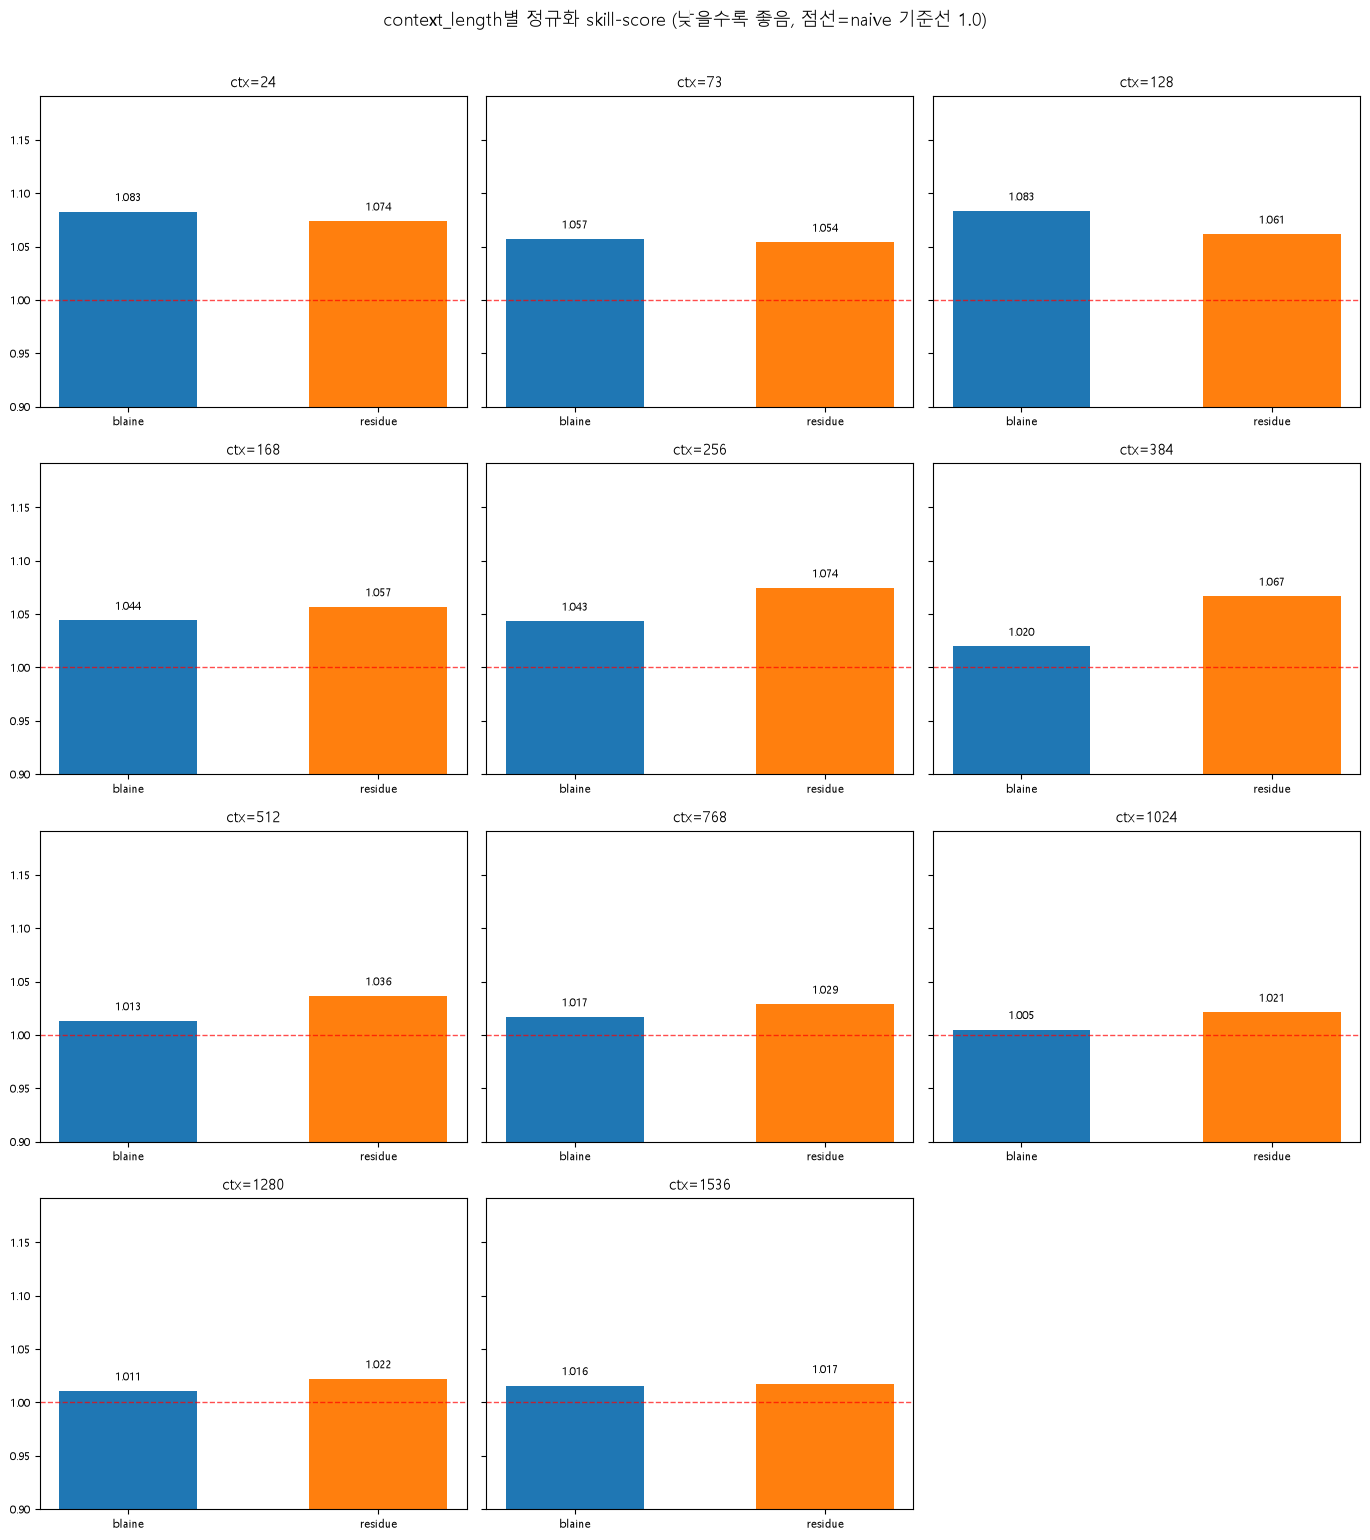

In [4]:
scores = {t: {} for t in TARGETS}
for target in TARGETS:
    for ctx in CONTEXTS:
        df = full_raw[target].get(ctx)
        if df is not None:
            scores[target][ctx] = normalized_skill_score(df)

ncols = 3
nrows = -(-len(CONTEXTS) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.8 * nrows), sharey=True)
axes = axes.flatten()

bar_colors = {"blaine": "tab:blue", "residue": "tab:orange"}
y_max = max(v for t in TARGETS for v in scores[t].values()) * 1.1

for i, ctx in enumerate(CONTEXTS):
    ax = axes[i]
    vals = [scores[t].get(ctx, np.nan) for t in TARGETS]
    bars = ax.bar(TARGETS, vals, color=[bar_colors[t] for t in TARGETS], width=0.55)
    ax.axhline(1.0, color="red", linestyle="--", linewidth=1, alpha=0.7)
    for b, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.3f}", ha="center", fontsize=8)
    ax.set_title(f"ctx={ctx}", fontsize=11)
    ax.set_ylim(0.9, y_max)
    ax.tick_params(labelsize=8)

for j in range(len(CONTEXTS), len(axes)):
    axes[j].axis("off")

fig.suptitle("context_length별 정규화 skill-score (낮을수록 좋음, 점선=naive 기준선 1.0)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 4. Context Length에 따른 추세 (정규화 skill-score, 꺾은선)

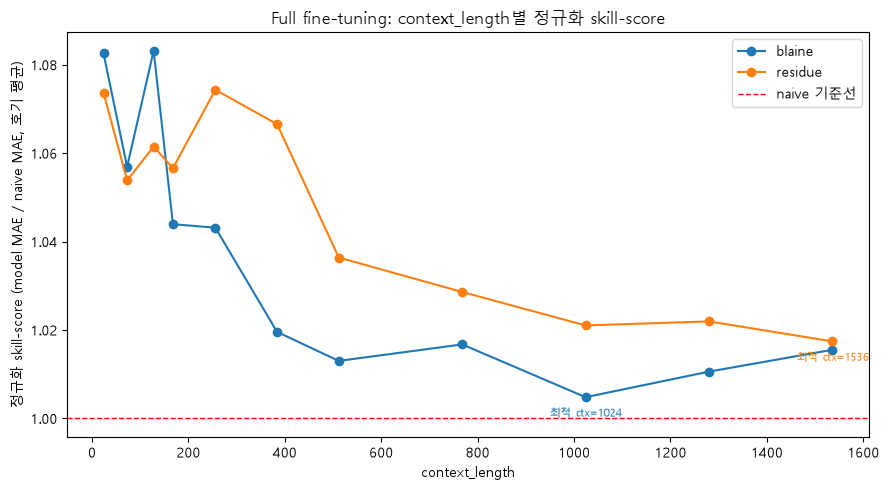

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
for target in TARGETS:
    xs = [c for c in CONTEXTS if c in scores[target]]
    ys = [scores[target][c] for c in xs]
    ax.plot(xs, ys, marker="o", label=target, color=bar_colors[target])
    best_ctx = min(xs, key=lambda c: scores[target][c])
    ax.annotate(f"최적 ctx={best_ctx}", (best_ctx, scores[target][best_ctx]),
                textcoords="offset points", xytext=(0, -14), ha="center", fontsize=8, color=bar_colors[target])

ax.axhline(1.0, color="red", linestyle="--", linewidth=1, label="naive 기준선")
ax.set_xlabel("context_length")
ax.set_ylabel("정규화 skill-score (model MAE / naive MAE, 호기 평균)")
ax.set_title("Full fine-tuning: context_length별 정규화 skill-score")
ax.legend()
plt.tight_layout()
plt.show()

## 5. 순위표 (정규화 / macro / pooled 나란히 비교)

In [6]:
for target in TARGETS:
    rows = []
    for ctx in CONTEXTS:
        df = full_raw[target].get(ctx)
        if df is None:
            continue
        rows.append({
            "ctx": ctx,
            "정규화 skill-score": round(normalized_skill_score(df), 4),
            "macro MAE": round(macro_average_mae(df), 3),
            "pooled MAE": round(compute_metrics(df, cfg.SPEC_RANGES[target])["MAE"], 3),
        })
    t = pd.DataFrame(rows).sort_values("정규화 skill-score").reset_index(drop=True)
    print(f"=== {target} (정규화 skill-score 기준 순위) ===")
    print(t.to_string(index=False))
    print(f"  -> 최적 context_length = {int(t.iloc[0]['ctx'])}")
    print()

=== blaine (정규화 skill-score 기준 순위) ===
 ctx  정규화 skill-score  macro MAE  pooled MAE
1024           1.0048     63.504      63.518
1280           1.0106     63.839      63.858
 512           1.0130     64.153      64.183
1536           1.0155     64.122      64.132
 768           1.0167     64.288      64.312
 384           1.0196     64.464      64.504
 256           1.0431     65.922      65.958
 168           1.0439     65.874      65.889
  73           1.0569     66.636      66.656
  24           1.0826     68.245      68.242
 128           1.0832     68.511      68.508
  -> 최적 context_length = 1024

=== residue (정규화 skill-score 기준 순위) ===
 ctx  정규화 skill-score  macro MAE  pooled MAE
1536           1.0174      0.422       0.421
1024           1.0210      0.424       0.424
1280           1.0219      0.424       0.423
 768           1.0286      0.427       0.427
 512           1.0364      0.430       0.430
  73           1.0538      0.438       0.437
 168           1.0566      0.439   

## 6. 상세 성능 지표 (11개 context_length, Full fine-tuning)

skill-score(정규화, 3~5절)만으로는 "실제 예측이 얼마나 정확한지"가 잘 안 와닿아서, **해석 가능한
절대 지표**를 context_length에 따른 꺾은선 그래프로 정리합니다. 전부 **pooled**(2CM/3CM/4CM 세 호기
예측을 한 번에 모아서 계산) 기준:

| 지표 | 의미 | 좋은 방향 |
|---|---|---|
| **MAE** | 평균 절대 오차 (blaine은 ㎠/g, residue는 %p) | 낮을수록 |
| **R²** | 실측 분산 중 모델이 설명하는 비율 | 높을수록 |
| **Spec 정확도** | 규격 판정(IN/OUT_OF_SPEC)이 실측과 일치한 비율 (blaine 3700–3900, residue 7–9) | 높을수록 |
| **80% 커버리지** | 실측이 모델의 80% 예측구간(q10~q90) 안에 든 비율 | **0.80에 가까울수록** (초록 점선) |

그래프는 **① blaine·residue를 한 그림에**(2×4), 그리고 **② 각각 따로 한 그림씩**(2×2) 렌더링합니다.
x축은 등간격으로 놓은 context_length입니다. (최적 context_length는 5절 순위표 참고)

In [7]:
# --- 지표 계산 (pooled) + 그래프 헬퍼 -----------------------------------------
PLOT_METRICS = ["MAE", "R²", "Spec 정확도", "80% 커버리지"]  # 6절에서 그래프로 그릴 지표

METRIC_BEST = {
    "MAE": "min", "R²": "max", "Spec 정확도": "max",
    "80% 커버리지": ("target", 0.80), "skill-score": "min",
}


def metrics_table(target: str, contexts, raw_store) -> pd.DataFrame:
    """index=context_length, columns=[MAE, R², Spec 정확도, 80% 커버리지, skill-score] (pooled)."""
    rows = {}
    for ctx in contexts:
        df = raw_store[target].get(ctx)
        if df is None:
            continue
        m = compute_metrics(df, cfg.SPEC_RANGES[target])
        rows[ctx] = {
            "MAE": m["MAE"],
            "R²": m["R2"],
            "Spec 정확도": m["spec_accuracy"],
            "80% 커버리지": m.get("interval_coverage", np.nan),
            "skill-score": normalized_skill_score(df),
        }
    out = pd.DataFrame(rows).T
    out.index.name = "ctx"
    return out


def _best_ctx(series: pd.Series, rule):
    s = series.dropna()
    if s.empty:
        return None
    if rule == "min":
        return s.idxmin()
    if rule == "max":
        return s.idxmax()
    if isinstance(rule, tuple) and rule[0] == "target":
        return (s - rule[1]).abs().idxmin()
    return None


bar_colors = {"blaine": "tab:blue", "residue": "tab:orange"}


def _style_ctx_axis(ax, ctx_values):
    """x축을 등간격 위치로 두고 context_length 값을 라벨로 (log축의 오른쪽 쏠림 방지)."""
    xs = list(range(len(ctx_values)))
    ax.set_xticks(xs)
    ax.set_xticklabels(ctx_values, rotation=45, fontsize=7)
    ax.set_xlabel("context_length", fontsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.margins(x=0.06)
    ax.grid(True, alpha=0.25)


def plot_metric_trend(ax, series: pd.Series, metric: str, color: str, label: str | None = None):
    """context_length(등간격)에 따른 한 지표의 꺾은선."""
    s = series.dropna()
    ctxs = list(s.index)
    xs = list(range(len(ctxs)))
    ax.plot(xs, s.values, marker="o", markersize=5, linewidth=1.6, color=color, label=label)
    if metric == "80% 커버리지":
        ax.axhline(0.80, color="green", linestyle="--", linewidth=1, alpha=0.7)
        ax.set_ylim(min(0.38, s.min() - 0.05), 0.86)
    _style_ctx_axis(ax, ctxs)


blaine_tbl = metrics_table("blaine", CONTEXTS, full_raw)
residue_tbl = metrics_table("residue", CONTEXTS, full_raw)
metric_tbls = {"blaine": blaine_tbl, "residue": residue_tbl}

with pd.option_context("display.float_format", lambda v: f"{v:,.4f}"):
    for t in TARGETS:
        print(f"=== {t} (Full fine-tuning, pooled) ===")
        print(metric_tbls[t].to_string())
        print()

=== blaine (Full fine-tuning, pooled) ===
         MAE     R²  Spec 정확도  80% 커버리지  skill-score
ctx                                                 
24   68.2422 0.3777    0.7018    0.4354       1.0826
73   66.6562 0.4010    0.6961    0.4657       1.0569
128  68.5077 0.3635    0.7041    0.5134       1.0832
168  65.8892 0.4164    0.7140    0.4806       1.0439
256  65.9576 0.4187    0.7100    0.4955       1.0431
384  64.5037 0.4540    0.7051    0.4707       1.0196
512  64.1827 0.4550    0.7100    0.4836       1.0130
768  64.3117 0.4574    0.7200    0.4608       1.0167
1024 63.5178 0.4803    0.7130    0.5015       1.0048
1280 63.8576 0.4762    0.7190    0.4677       1.0106
1536 64.1315 0.4731    0.7259    0.4052       1.0155

=== residue (Full fine-tuning, pooled) ===
        MAE     R²  Spec 정확도  80% 커버리지  skill-score
ctx                                                
24   0.4454 0.8018    0.7967    0.4566       1.0737
73   0.4371 0.8158    0.8090    0.5097       1.0538
128  0.4401 0.811

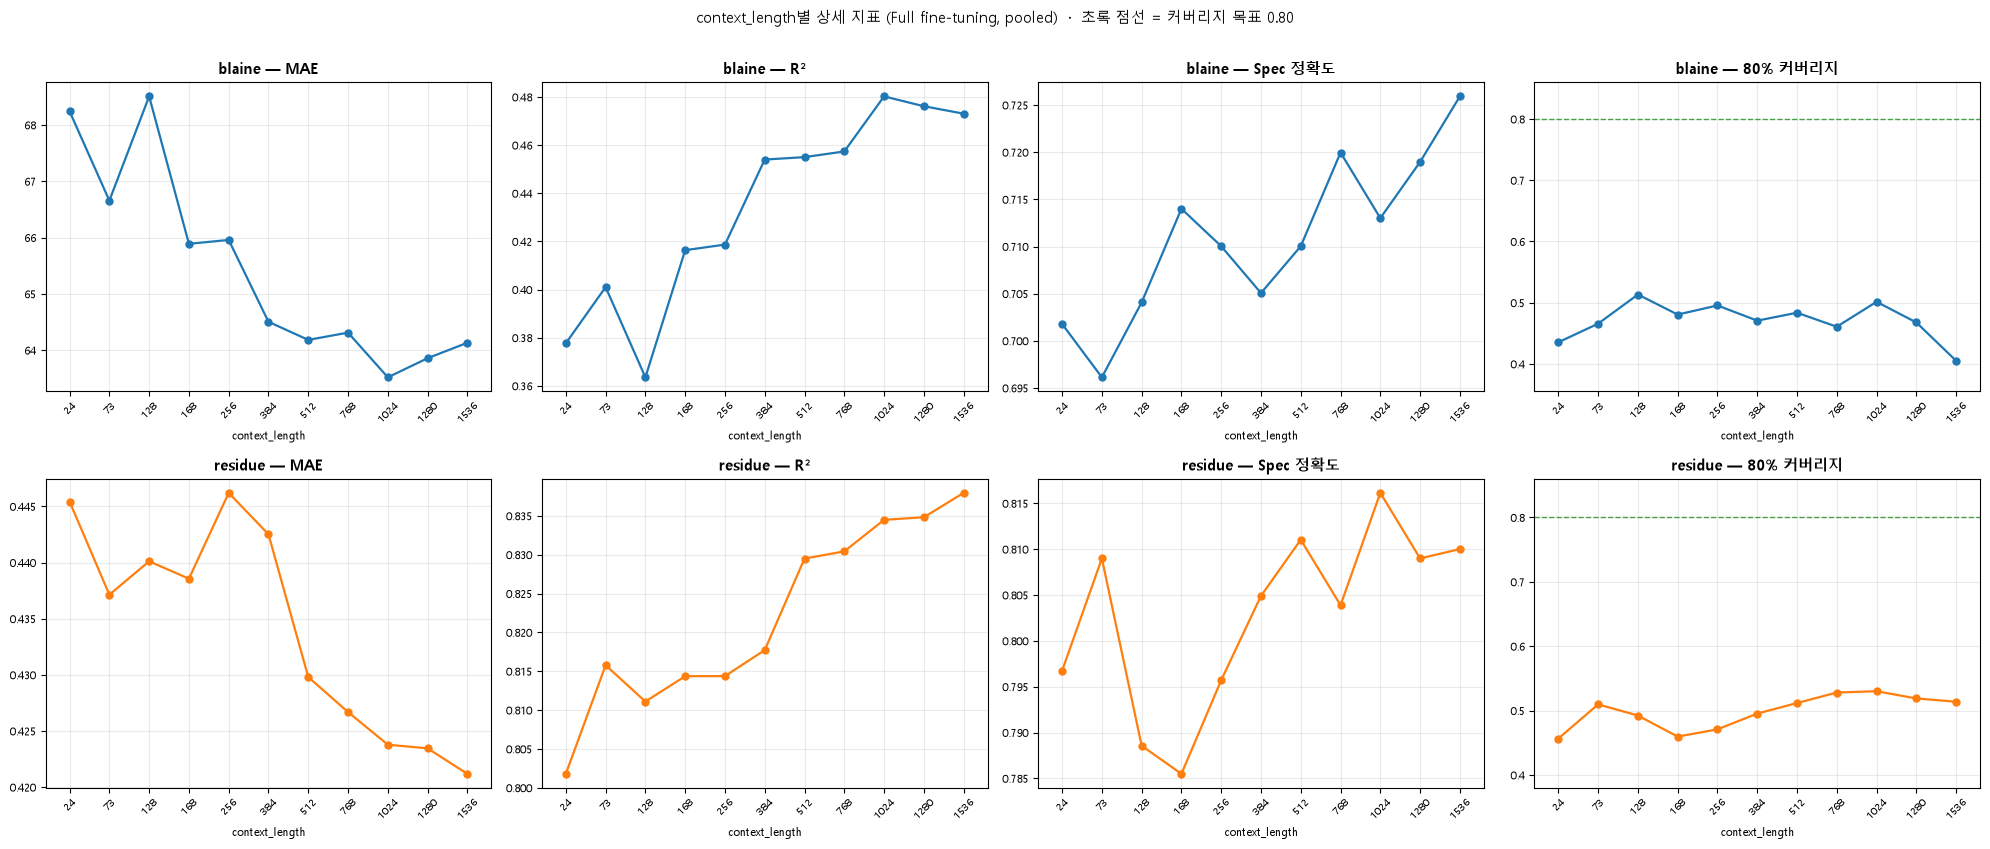

In [8]:
# --- ① blaine + residue 를 한 그림에 (2행 x 4지표) ---------------------------
fig, axes = plt.subplots(len(TARGETS), len(PLOT_METRICS), figsize=(5.0 * len(PLOT_METRICS), 4.2 * len(TARGETS)))
for i, target in enumerate(TARGETS):
    for j, metric in enumerate(PLOT_METRICS):
        ax = axes[i, j]
        plot_metric_trend(ax, metric_tbls[target][metric], metric, bar_colors[target])
        ax.set_title(f"{target} — {metric}", fontsize=11, fontweight="bold")
fig.suptitle(
    "context_length별 상세 지표 (Full fine-tuning, pooled)  ·  초록 점선 = 커버리지 목표 0.80",
    fontsize=11, y=1.005,
)
plt.tight_layout()
plt.show()

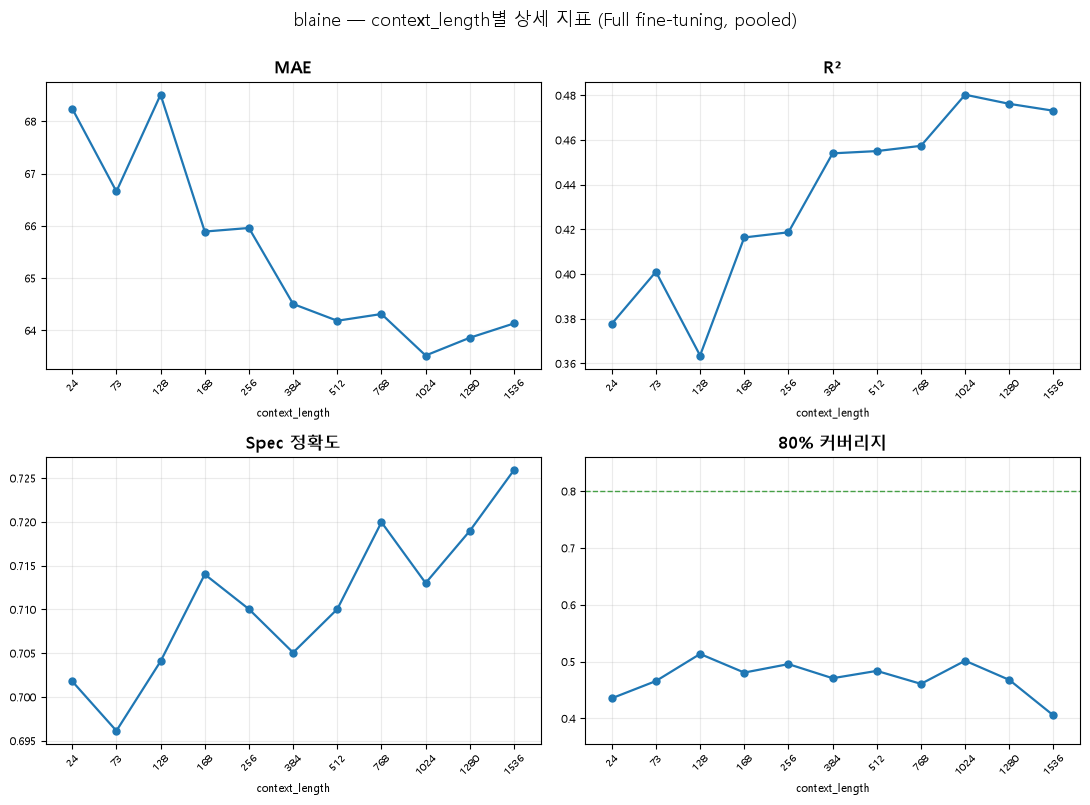

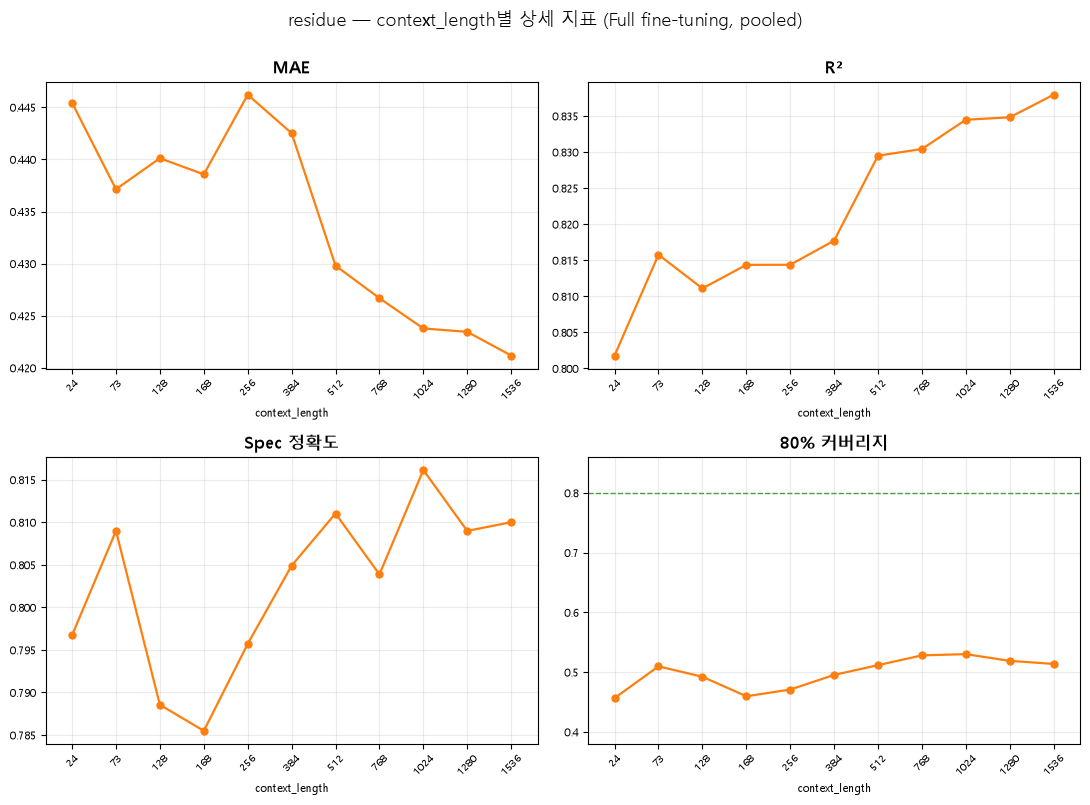

In [9]:
# --- ② blaine / residue 각각 따로 한 그림씩 (2 x 2 지표) ---------------------
for target in TARGETS:
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    for ax, metric in zip(axes.flatten(), PLOT_METRICS):
        plot_metric_trend(ax, metric_tbls[target][metric], metric, bar_colors[target])
        ax.set_title(metric, fontsize=12, fontweight="bold")
    fig.suptitle(f"{target} — context_length별 상세 지표 (Full fine-tuning, pooled)", fontsize=13, y=1.0)
    plt.tight_layout()
    plt.show()

## 7. zero-shot / LoRA / Full fine-tuning 비교 (11개 context_length 전체)

세 방식 모두 11개 context_length(= "가중치") 전부 backtest 되어 있습니다. skill-score 대신 **해석
가능한 절대 지표(MAE / R² / Spec 정확도 / 80% 커버리지)**를 그대로 써서, 모든 가중치에 대해 세 방식을
비교합니다.

- **꺾은선 (2×4)**: 행 = blaine / residue, 열 = MAE / R² / Spec 정확도 / 80% 커버리지. 한 패널에
  세 방식(zero-shot·LoRA·Full) 선을 겹쳐 그립니다. x축은 등간격으로 놓은 context_length입니다.
  MAE는 낮을수록, R²·Spec 정확도는 높을수록 좋고, 80% 커버리지는 초록 점선(0.80)에 가까울수록
  좋습니다.
- **표**: 마지막에 가중치(context_length)별로 세 방식 각각의 실제값 — MAE / R² / Spec 정확도 /
  80% 커버리지 — 을 표로 정리합니다. (전부 pooled: 2CM/3CM/4CM 세 호기를 한 번에 모아 계산)

3개 방식 x 11개 context_length x 2 타깃 = 66 개 결과 파일 전부 로딩 완료


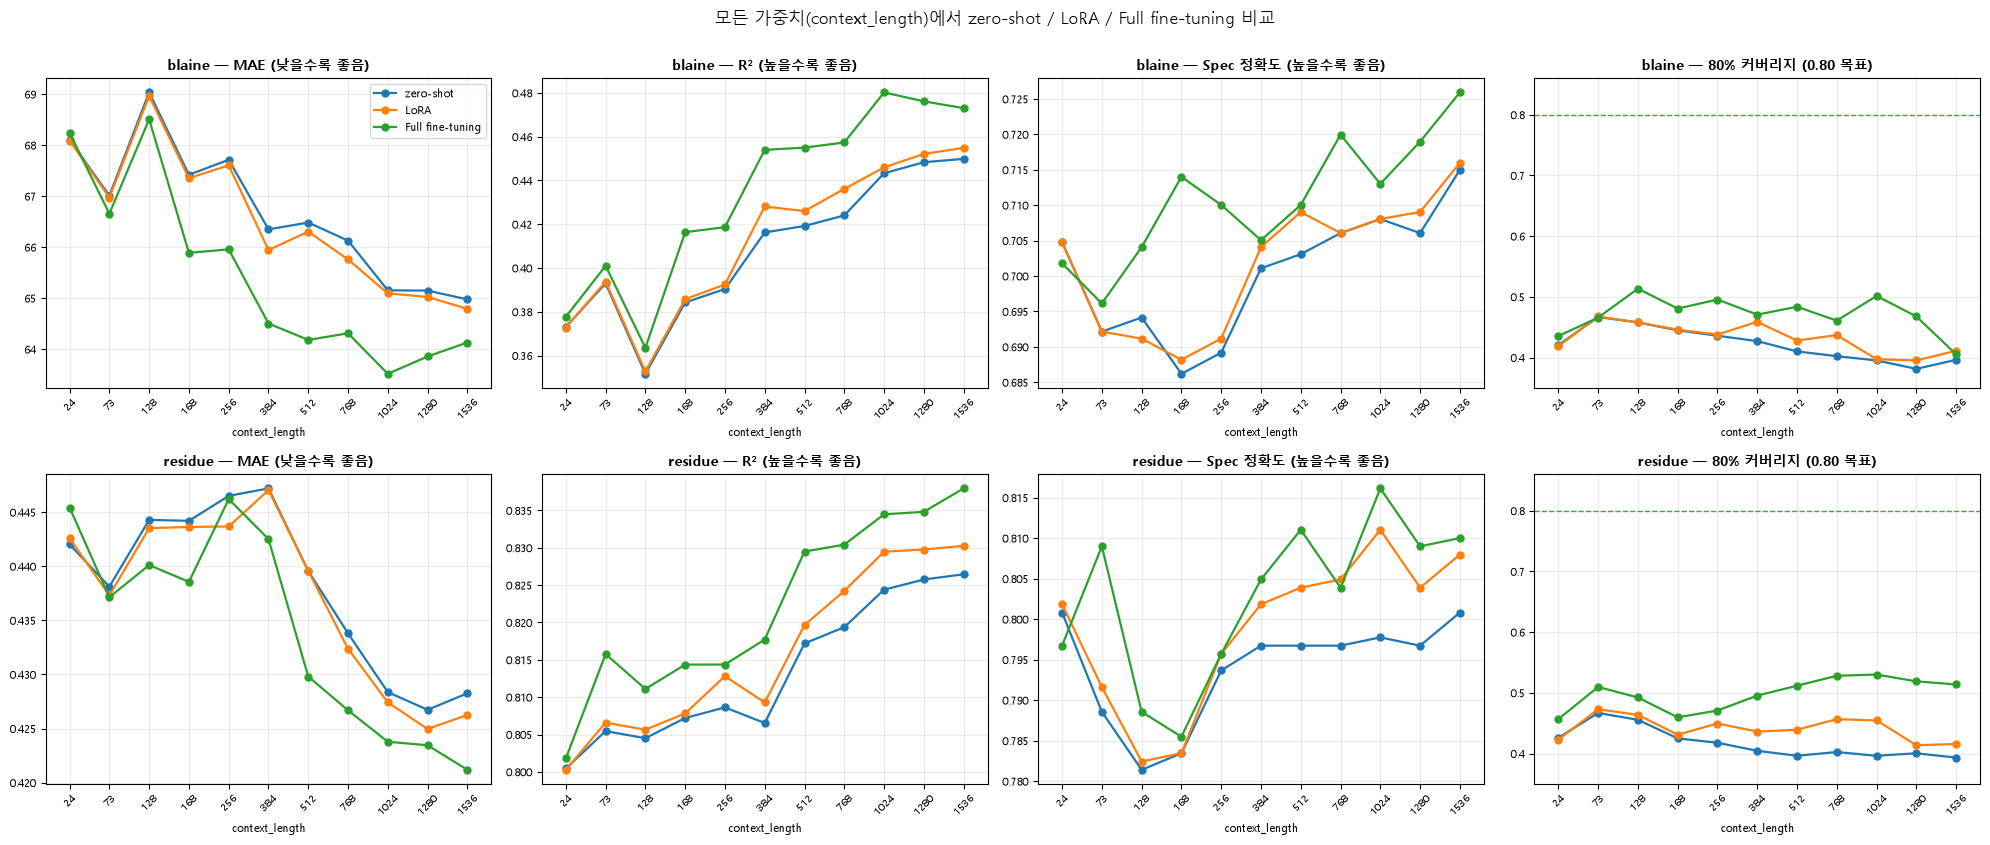

In [10]:
# --- 세 방식 x 11개 context_length backtest 로딩 -------------------------------
appendix_raw = {t: {} for t in TARGETS}
appendix_missing = []
for target in TARGETS:
    for ctx in CONTEXTS_ALL_METHODS:
        appendix_raw[target][ctx] = {}
        for method in METHODS:
            p = backtest_path(target, ctx, method)
            if p.exists():
                appendix_raw[target][ctx][method] = pd.read_csv(p, parse_dates=["timestamp"])
            else:
                appendix_missing.append(str(p))

if appendix_missing:
    print("[missing]", len(appendix_missing), "files:")
    for m in appendix_missing:
        print(" ", m)
else:
    print("3개 방식 x 11개 context_length x 2 타깃 =",
          sum(len(appendix_raw[t][c]) for t in TARGETS for c in CONTEXTS_ALL_METHODS), "개 결과 파일 전부 로딩 완료")

# --- 방식 x context_length 별 절대 지표 표 (pooled) ---------------------------
APPENDIX_METRICS = ["MAE", "R²", "Spec 정확도", "80% 커버리지"]


def _abs_metrics(df: pd.DataFrame, spec) -> dict:
    m = compute_metrics(df, spec)
    return {
        "MAE": m["MAE"],
        "R²": m["R2"],
        "Spec 정확도": m["spec_accuracy"],
        "80% 커버리지": m.get("interval_coverage", np.nan),
    }


# appendix_metric_tbls[target][method] : index=context_length, columns=APPENDIX_METRICS
appendix_metric_tbls = {t: {} for t in TARGETS}
for target in TARGETS:
    spec = cfg.SPEC_RANGES[target]
    for method in METHODS:
        rows = {}
        for ctx in CONTEXTS_ALL_METHODS:
            df = appendix_raw[target][ctx].get(method)
            if df is not None:
                rows[ctx] = _abs_metrics(df, spec)
        tbl = pd.DataFrame(rows).T
        tbl.index.name = "ctx"
        appendix_metric_tbls[target][method] = tbl

method_colors = {"zero-shot": "tab:blue", "LoRA": "tab:orange", "Full fine-tuning": "tab:green"}

# --- 꺾은선 (2행 target x 4열 metric), 패널마다 세 방식 겹쳐 그리기 -----------
fig, axes = plt.subplots(len(TARGETS), len(APPENDIX_METRICS),
                         figsize=(5.0 * len(APPENDIX_METRICS), 4.2 * len(TARGETS)))
for i, target in enumerate(TARGETS):
    for j, metric in enumerate(APPENDIX_METRICS):
        ax = axes[i, j]
        for method in METHODS:
            s = appendix_metric_tbls[target][method][metric].dropna()
            ax.plot(range(len(s)), s.values, marker="o", markersize=5, linewidth=1.6,
                    color=method_colors[method], label=method)
        if metric == "80% 커버리지":
            ax.axhline(0.80, color="green", linestyle="--", linewidth=1, alpha=0.7)
            ax.set_ylim(0.35, 0.86)
        _style_ctx_axis(ax, CONTEXTS_ALL_METHODS)
        direction = "낮을수록 좋음" if metric == "MAE" else ("0.80 목표" if metric == "80% 커버리지" else "높을수록 좋음")
        ax.set_title(f"{target} — {metric} ({direction})", fontsize=10, fontweight="bold")
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
fig.suptitle("모든 가중치(context_length)에서 zero-shot / LoRA / Full fine-tuning 비교", fontsize=12, y=1.0)
plt.tight_layout()
plt.show()


In [11]:
# --- 가중치(context_length)별 실제값 표: 방식 x 지표 --------------------------
#   각 타깃마다 index=context_length, columns=(방식, 지표) 형태로 정리.
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

for target in TARGETS:
    combined = pd.concat(
        {method: appendix_metric_tbls[target][method] for method in METHODS},
        axis=1,
    )
    combined = combined.reindex(CONTEXTS_ALL_METHODS)
    combined.index.name = "ctx"
    with pd.option_context("display.float_format", lambda v: f"{v:,.4f}"):
        print(f"=== {target} — 가중치(context_length)별 실제값 (pooled) ===")
        print(combined.to_string())
        print()

# --- 방식별로 나눠서 각각 한 표씩 (읽기 편한 버전) --------------------------
for target in TARGETS:
    for method in METHODS:
        tbl = appendix_metric_tbls[target][method].reindex(CONTEXTS_ALL_METHODS)
        with pd.option_context("display.float_format", lambda v: f"{v:,.4f}"):
            print(f"--- {target} · {method} ---")
            print(tbl.to_string())
            print()


=== blaine — 가중치(context_length)별 실제값 (pooled) ===
     zero-shot                             LoRA                          Full fine-tuning                         
           MAE     R² Spec 정확도 80% 커버리지     MAE     R² Spec 정확도 80% 커버리지              MAE     R² Spec 정확도 80% 커버리지
ctx                                                                                                               
24     68.1074 0.3731   0.7048   0.4205 68.0900 0.3728   0.7048   0.4185          68.2422 0.3777   0.7018   0.4354
73     67.0112 0.3930   0.6922   0.4667 66.9730 0.3938   0.6922   0.4677          66.6562 0.4010   0.6961   0.4657
128    69.0347 0.3517   0.6941   0.4578 68.9650 0.3527   0.6912   0.4578          68.5077 0.3635   0.7041   0.5134
168    67.4206 0.3843   0.6862   0.4449 67.3528 0.3857   0.6882   0.4459          65.8892 0.4164   0.7140   0.4806
256    67.7133 0.3904   0.6892   0.4359 67.6058 0.3925   0.6912   0.4379          65.9576 0.4187   0.7100   0.4955
384    66.3497 0.4163   0.701

## 8. 결론

- **정규화 skill-score 기준으로도 결론은 그대로입니다**: blaine 최적 `context_length=1024`,
  residue 최적 `context_length=1536` — pooled MAE / macro-average MAE / 정규화 skill-score 세
  방식이 (74~1536 구간에서) 전부 동일한 승자를 냈습니다. 즉 지금까지의 선택은 집계 방식과 무관하게
  견고합니다.
- **6절의 상세 지표 그래프**가 이 선택을 뒷받침합니다: 최적 context_length 근처에서 MAE가 가장 낮고,
  R² / Spec 정확도도 상위권입니다. 다만 **80% 예측구간 커버리지는 0.40~0.53로 목표(0.80)에 한참
  못 미칩니다** — 모델의 예측구간(q10~q90)이 지나치게 좁다(과신)는 뜻이고, context_length 선택과는
  별개로 따로 볼 이슈입니다.
- **7절 방식 비교 그래프**: 쓸모 있는 구간(`context_length >= 73`)에서는 **모든 가중치(context_length)**에
  대해 blaine·residue 둘 다 Full fine-tuning의 MAE가 zero-shot / LoRA보다 낮고 R²·Spec 정확도도
  높습니다(초록 선이 MAE 패널에서 항상 가장 아래). 유일한 예외는 `context_length=24`(약 하루치)인데,
  여기선 세 방식 다 naive보다 못한 데다 차이도 오차 수준이라 순위가 뒤집힐 뿐입니다. LoRA는
  zero-shot보다는 낫지만 Full에 못 미칩니다 → Full fine-tuning 채택이 데이터로 납득됩니다.
  (80% 커버리지는 세 방식 모두 비슷하게 낮아, 방식과 무관하게 예측구간이 과신 상태입니다.)
- **`context_length=24`(약 하루치)는 이번에 새로 backtest해서 확인한 결과, 예상대로 가장 나쁩니다**
  — blaine은 naive baseline(MAE 63.09)보다도 못한 MAE 68.24를 기록했습니다. context가 너무 짧으면
  naive만도 못한 상태가 될 수 있다는 걸 보여주는 사례입니다.
- **loss curve(2절)는 대부분(ctx 73~1024) backtest와 다른(같은 설정을 나중에 다시 돌린 "_v2") 학습
  실행**이라는 점을 감안해서 참고만 하세요 — 이 대화에서 여러 번 확인했듯 같은 설정도 재학습마다
  결과가 흔들릴 수 있어서, "이 loss curve가 정확히 옆 숫자를 만들어낸 학습"이라고 단정할 수는
  없습니다.
- **다음 단계**: 512 미만 구간의 비단조적 패턴(128 근처 dip 등), 1536 이후(2048 등) 추가 개선
  여부, 그리고 위의 예측구간 과신(80% 커버리지 << 0.80) 문제는 여전히 미해결로 남아 있습니다.